# belief eye neural analysis


## imports

In [36]:
%reload_ext autoreload
%autoreload 2

In [37]:
import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)

In [38]:
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA

In [39]:
# misc
import pickle
from collections import defaultdict

In [40]:
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

# load data

## load standard data


In [41]:
df = pd.read_pickle(resdir/'0417_m51df.pkl')
len(df)
df=df[df.session==41]

In [42]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [43]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


In [44]:
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [45]:
# make a df by time (each row is a time, instead of a trial)
sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timedf=pd.DataFrame({'timer':timer})
timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))

timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))

timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
timedf['error']=np.concatenate(sessdf.error_t.to_numpy())


timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timedf.head()
timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

In [46]:
timedf.columns                                                           

Index(['timer', 'rawcov', 'belief', 'state', 'eye', 'timeratio', 'mv', 'mw',
       'belief_heading', 'countdown', 'belief_angle_from_start', 'PPC',
       'uncertainty', 'density', 'fullon', 'error', 'dbelief', 'deye',
       'dneural'],
      dtype='object')

## load iti data

In [47]:
itidf = pd.read_pickle(resdir/'0421iti_m51df.pkl')
len(itidf)
itidf=itidf[itidf.session==41]
itidf['time_ratio']=itidf.apply(lambda x: x.timer/x.timer[-1], axis=1)

In [48]:
for session in sorted(itidf.session.unique())[:1]:
    sessitidf=itidf[(itidf.session==session)]

# state=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessitidf.ff_hori.to_numpy())
eye=np.concatenate(sessitidf.eye_hori.to_numpy())
timeratio=np.concatenate(sessitidf.time_ratio.to_numpy())
timer=np.concatenate(sessitidf.timer.to_numpy())
countdown=np.concatenate(sessitidf.countdown.to_numpy())

# make a itidf by time (each row is a time, instead of a trial)
sessitidf['density_t']=sessitidf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['fullon_t']=sessitidf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['error_t']=sessitidf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timeitidf=pd.DataFrame({'timer':timer})
# timeitidf['rawcov']=list(np.vstack(sessitidf['rawcov'].to_numpy()))
# timeitidf['belief']=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
timeitidf['state']=np.concatenate(sessitidf.ff_hori.to_numpy())
timeitidf['eye']=np.concatenate(sessitidf.eye_hori.to_numpy())
timeitidf['timeratio']=np.concatenate(sessitidf.time_ratio.to_numpy())
timeitidf['mv']=np.concatenate(sessitidf.mv.to_numpy())
timeitidf['mw']=np.concatenate(sessitidf.mw.to_numpy())
# timeitidf['belief_heading']=np.concatenate(sessitidf.belief_heading.to_numpy())
timeitidf['timer']=np.concatenate(sessitidf.timer.to_numpy())
timeitidf['countdown']=np.concatenate(sessitidf.countdown.to_numpy())
# timeitidf['belief_angle_from_start']=np.concatenate(sessitidf.belief_angle_from_start.to_numpy())
timeitidf['PPC']=list(np.vstack(sessitidf.PPC.to_numpy()))

# timeitidf['uncertainty']=list(np.concatenate(sessitidf.relcov.to_numpy()))

timeitidf['density']=np.concatenate(sessitidf.density_t.to_numpy())
timeitidf['fullon']=np.concatenate(sessitidf.fullon_t.to_numpy())
timeitidf['error']=np.concatenate(sessitidf.error_t.to_numpy())


# timeitidf['dbelief']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['deye']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['dneural']=list(np.vstack(sessitidf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timeitidf.head()
# timeitidf = timeitidf.dropna(subset=['eye', 'state'])

,timer,state,eye,timeratio,mv,mw,countdown,PPC,density,fullon,error,deye,dneural
0,0,-0.411339,28.940651,0.000000,-0.003190,-0.001378,-37,"[0.106192164, 0.19640955, 0.0, 0.0, 0.05650172...",0.005,0,174.501175,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,1,-0.470667,28.920336,0.027027,0.023303,0.007235,-36,"[0.10775572, 0.1846899, 0.0, 3.3458742e-05, 0....",0.005,0,174.501175,-0.020315,"[0.0015635565, -0.011719659, 0.0, 3.3458742e-0..."
2,2,-0.533338,28.902283,0.054054,-0.004524,-0.002155,-35,"[0.109807715, 0.16330647, 0.0, 8.815204e-05, 0...",0.005,0,174.501175,-0.018053,"[0.0020519942, -0.02138342, 0.0, 5.4693297e-05..."
3,3,-0.500699,28.880598,0.081081,-0.015537,-0.000820,-34,"[0.110675946, 0.13578184, 0.0, 0.0002181784, 0...",0.005,0,174.501175,-0.021685,"[0.00086823106, -0.027524635, 0.0, 0.000130026..."
4,4,-0.481149,28.881540,0.108108,0.015418,0.008251,-33,"[0.10878229, 0.10615871, 0.0, 0.00050727994, 0...",0.005,0,174.501175,0.000942,"[-0.0018936545, -0.029623128, 0.0, 0.000289101..."


# Regression and residual regression

## binning by time (time ratio) and space (abs diff, diff in derivative)

Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,), TimeRatio=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,), TimeRatio=(399510,)

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399510, 112)

--- Time-Binned Analysis Comparison (50 bins) ---

Processing Bin 1/50 (TimeRatio: 0.00 to 0.02)...
  Samples in bin: 9346
  Calculating Total Belief Encoding (Neural -> Belief)...
    CV Pearson r (Total): 0.3592, p=1.03e-282
  Calculating Independent Belief Encoding (Residuals -> Belief)...
    CV Pearson r (Independent): 0.3589, p=4.42e-282

Processing Bin 2/50

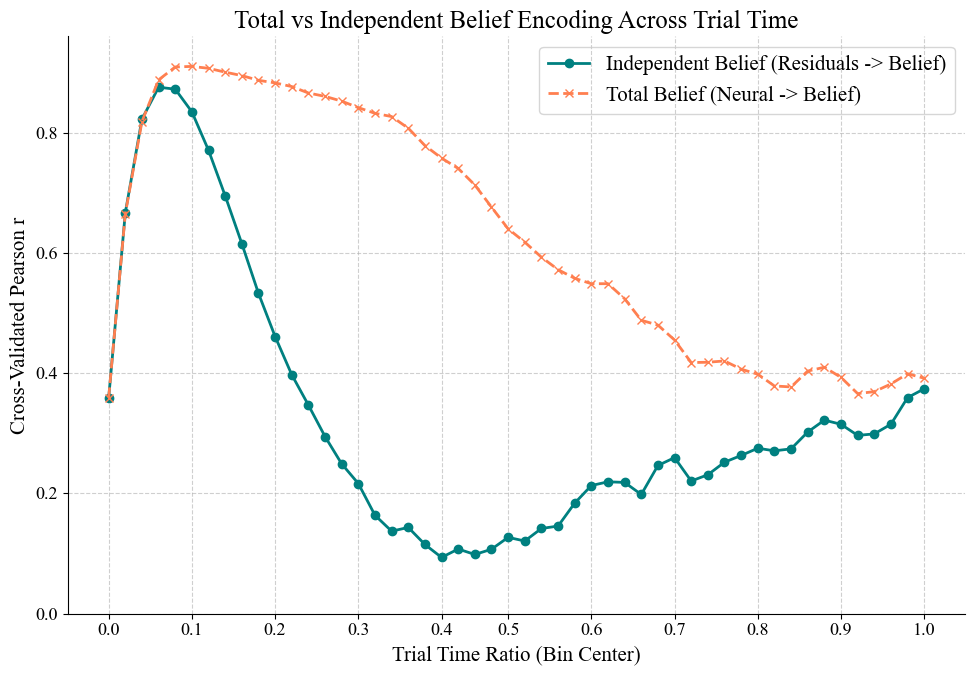


Time-Binned Comparison Analysis Complete.


In [89]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Need more samples for binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial # Adjust total samples
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 50 # Number of bins for timeratio (Adjust if needed)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Time-Binned Analysis Comparison
# =============================================================================
print(f"\n--- Time-Binned Analysis Comparison ({n_time_bins} bins) ---")

# Define time bins
bin_edges = np.linspace(0, 1, n_time_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
results_r_independent = [] # Pearson r for Residuals -> Belief
results_r_total = []       # Pearson r for Neural -> Belief
actual_bin_centers = []    # Store centers only for bins with enough data

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_time_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    is_last_bin = (i == n_time_bins - 1)
    if is_last_bin:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present <= bin_end)
    else:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_time_bins} (TimeRatio: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r_independent.append(np.nan)
        results_r_total.append(np.nan)
        continue

    # --- Perform CV analyses within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # --- 1. Total Belief Encoding (Neural -> Belief) ---
    print("  Calculating Total Belief Encoding (Neural -> Belief)...")
    predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
    valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
    if np.sum(valid_indices_total) < 2:
        r_total_bin, p_total_bin = np.nan, np.nan
    else:
        r_total_bin, p_total_bin = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
    print(f"    CV Pearson r (Total): {r_total_bin:.4f}, p={p_total_bin:.2e}")
    results_r_total.append(r_total_bin)


    # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
    print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
    # a. Get CV predictions for Neural ~ Eye within bin
    predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
    # b. Calculate Residuals within bin
    residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
    # c. Get CV predictions for Belief ~ Residuals within bin
    predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
    # d. Evaluate Belief prediction for this bin
    valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
    if np.sum(valid_indices_independent) < 2:
        r_independent_bin, p_independent_bin = np.nan, np.nan
    else:
        r_independent_bin, p_independent_bin = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])
    print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}, p={p_independent_bin:.2e}")
    results_r_independent.append(r_independent_bin)

    # Store bin center if calculations were successful
    actual_bin_centers.append(bin_centers[i])


# =============================================================================
# Plotting the Time-Binned Comparison
# =============================================================================
print("\n--- Plotting Time-Binned Comparison ---")
fig_timebin_comp, ax_timebin_comp = plt.subplots(figsize=(10, 7)) # Slightly wider plot

# Filter out NaN results if bins were skipped
valid_results_mask = ~np.isnan(results_r_independent) & ~np.isnan(results_r_total) # Ensure both are valid
plot_centers = np.array(actual_bin_centers)
plot_r_independent = np.array(results_r_independent)[valid_results_mask]
plot_r_total = np.array(results_r_total)[valid_results_mask]

if len(plot_centers) > 0:
    # Plot Independent Belief Encoding (Residuals -> Belief)
    ax_timebin_comp.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', label='Independent Belief (Residuals -> Belief)')
    # Plot Total Belief Encoding (Neural -> Belief)
    ax_timebin_comp.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', label='Total Belief (Neural -> Belief)')

    ax_timebin_comp.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin_comp.set_ylabel('Cross-Validated Pearson r')
    ax_timebin_comp.set_title('Total vs Independent Belief Encoding Across Trial Time')
    # Adjust y-limits based on the range of both plots
    min_y = min(0, np.nanmin(results_r_independent) - 0.05, np.nanmin(results_r_total) - 0.05)
    max_y = max(0.1, np.nanmax(results_r_independent) + 0.05, np.nanmax(results_r_total) + 0.05)
    ax_timebin_comp.set_ylim(bottom=min_y, top=max_y)
    ax_timebin_comp.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_timebin_comp.axhline(0, color='black', linewidth=0.5, linestyle='--')
    # Set x-ticks to be bin centers (maybe fewer ticks if too cluttered)
    tick_indices = np.round(np.linspace(0, len(bin_centers)-1, 11)).astype(int) # Show ~11 ticks
    ax_timebin_comp.set_xticks(bin_centers[tick_indices])
    ax_timebin_comp.set_xticklabels([f"{c:.1f}" for c in bin_centers[tick_indices]])
    ax_timebin_comp.legend()

else:
    ax_timebin_comp.text(0.5, 0.5, 'No valid data bins found for plotting.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_timebin_comp.transAxes)
    ax_timebin_comp.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin_comp.set_ylabel('Cross-Validated Pearson r')
    ax_timebin_comp.set_title('Total vs Independent Belief Encoding Across Trial Time')


plt.tight_layout()
plt.show()

print("\nTime-Binned Comparison Analysis Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,)

--- Calculating Absolute Belief-Eye Difference ---
  Range of difference: 0.00 to 5.53

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399510, 112)

--- Belief-Eye Difference Binned Analysis Comparison (20 bins) ---

Processing Bin 1/20 (Belief-Eye Diff: 0.00 to 0.28)...
  Samples in bin: 110931
  Calculating Total Belief Encoding (Neural -> Belief)...
    CV Pearson r (Total): 0.5937
  Calculating Independent Belief Encoding (Residuals -> Belief)...
    CV Pearson

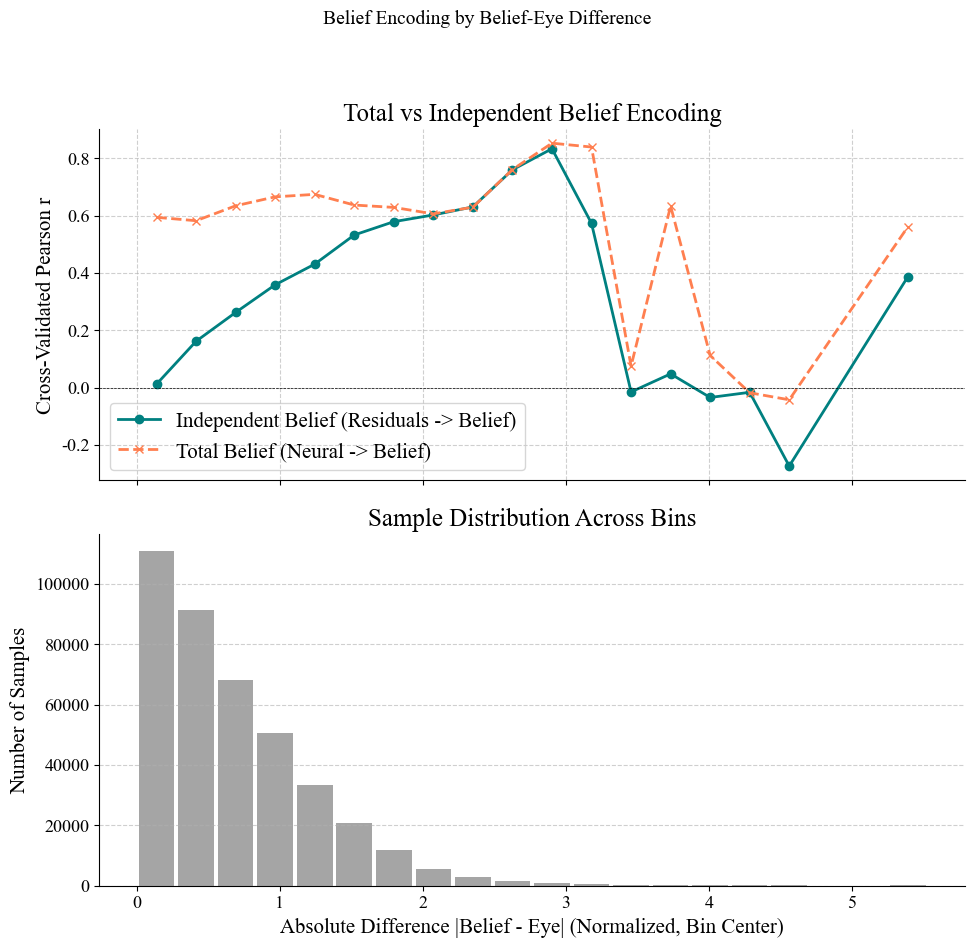


Belief-Eye Difference Binned Analysis Complete.


In [93]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Use a decent number of samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Simulate varying correlation - let's make it random per sample for simplicity here
     correlation_factor = rng.uniform(0.1, 0.8, n_samples_orig)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated
         # No timeratio needed for this version
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_diff_bins = 20 # Number of bins for belief-eye difference (Adjust as needed)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, or eye data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Calculate Belief-Eye Difference
# =============================================================================
print("\n--- Calculating Absolute Belief-Eye Difference ---")
belief_eye_diff = np.abs(belief_data_present - eye_data_present)
print(f"  Range of difference: {np.min(belief_eye_diff):.2f} to {np.max(belief_eye_diff):.2f}")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Belief-Eye Difference Binned Analysis Comparison
# =============================================================================
print(f"\n--- Belief-Eye Difference Binned Analysis Comparison ({n_diff_bins} bins) ---")

# Define difference bins (linear spacing)
min_diff = np.min(belief_eye_diff)
max_diff = np.max(belief_eye_diff)
# Add a small epsilon to max_diff to ensure the max value is included
bin_edges = np.linspace(min_diff, max_diff + 1e-9, n_diff_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

results_r_independent = [] # Pearson r for Residuals -> Belief
results_r_total = []       # Pearson r for Neural -> Belief
actual_bin_centers = []    # Store centers only for bins with enough data
samples_in_bins = []       # Store sample count per bin

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_diff_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    # Mask based on belief_eye_diff
    bin_mask = (belief_eye_diff >= bin_start) & (belief_eye_diff < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_diff_bins} (Belief-Eye Diff: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    samples_in_bins.append(n_samples_in_bin) # Store sample count regardless of whether bin is processed
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r_independent.append(np.nan)
        results_r_total.append(np.nan)
        continue # Skip to next bin

    # --- Perform CV analyses within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # --- 1. Total Belief Encoding (Neural -> Belief) ---
    print("  Calculating Total Belief Encoding (Neural -> Belief)...")
    predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
    valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
    if np.sum(valid_indices_total) < 2:
        r_total_bin = np.nan # Assign NaN if correlation cannot be computed
    else:
        # Use try-except for pearsonr as it can fail with constant arrays
        try:
            r_total_bin, _ = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
        except ValueError:
             r_total_bin = np.nan
    print(f"    CV Pearson r (Total): {r_total_bin:.4f}")
    results_r_total.append(r_total_bin)


    # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
    print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
    try:
        # a. Get CV predictions for Neural ~ Eye within bin
        predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
        # b. Calculate Residuals within bin
        residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
        # c. Get CV predictions for Belief ~ Residuals within bin
        predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
        # d. Evaluate Belief prediction for this bin
        valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
        if np.sum(valid_indices_independent) < 2:
            r_independent_bin = np.nan
        else:
            r_independent_bin, _ = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])

    except ValueError as e:
        # Catch potential errors during CV or correlation if data in bin is problematic
        print(f"    Error during independent calculation for bin {i+1}: {e}. Assigning NaN.")
        r_independent_bin = np.nan

    print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}")
    results_r_independent.append(r_independent_bin)

    # Store bin center only if both calculations were successful (not NaN)
    if not np.isnan(r_total_bin) and not np.isnan(r_independent_bin):
        actual_bin_centers.append(bin_centers[i])
    else:
        # If one failed, ensure the corresponding value in the other list is also NaN for plotting alignment
        if np.isnan(r_total_bin) and not np.isnan(r_independent_bin): results_r_independent[-1] = np.nan
        if not np.isnan(r_total_bin) and np.isnan(r_independent_bin): results_r_total[-1] = np.nan


# =============================================================================
# Plotting the Belief-Eye Difference Binned Comparison (Separate Plots)
# =============================================================================
print("\n--- Plotting Belief-Eye Difference Binned Comparison (Separate Plots) ---")
# Create figure with 2 subplots, sharing the x-axis
fig_diffbin_sep, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig_diffbin_sep.suptitle('Belief Encoding by Belief-Eye Difference', fontsize=14)

# --- Plot 1: Correlation Curves ---
ax_corr = axes[0]

# Filter out NaN results from skipped or failed bins for plotting
valid_results_mask = ~np.isnan(results_r_independent) & ~np.isnan(results_r_total)
# Ensure actual_bin_centers only contains centers where results are valid
# Note: actual_bin_centers is already built correctly based on successful calculations
plot_centers = np.array(actual_bin_centers)
# Filter the results arrays using the mask derived *before* appending NaNs for skipped bins
# Need to re-filter results based on the valid centers we have
plot_r_independent = np.array([r for r, mask in zip(results_r_independent, ~np.isnan(results_r_independent)) if mask])
plot_r_total = np.array([r for r, mask in zip(results_r_total, ~np.isnan(results_r_total)) if mask])

# Ensure lengths match after filtering potential NaNs from calculation errors
min_len = min(len(plot_centers), len(plot_r_independent), len(plot_r_total))
plot_centers = plot_centers[:min_len]
plot_r_independent = plot_r_independent[:min_len]
plot_r_total = plot_r_total[:min_len]


if len(plot_centers) > 0:
    # Plot Independent Belief Encoding (Residuals -> Belief)
    ax_corr.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', label='Independent Belief (Residuals -> Belief)')
    # Plot Total Belief Encoding (Neural -> Belief)
    ax_corr.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', label='Total Belief (Neural -> Belief)')

    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')
    # Adjust y-limits based on the range of both plots
    min_y = min(0, np.nanmin(plot_r_independent) - 0.05, np.nanmin(plot_r_total) - 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0
    max_y = max(0.1, np.nanmax(plot_r_independent) + 0.05, np.nanmax(plot_r_total) + 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0.1
    ax_corr.set_ylim(bottom=min_y, top=max_y)
    ax_corr.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_corr.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax_corr.legend()

else:
    ax_corr.text(0.5, 0.5, 'No valid data bins found for plotting correlations.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_corr.transAxes)
    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')


# --- Plot 2: Sample Count Histogram ---
ax_hist = axes[1]

if len(samples_in_bins) > 0:
    ax_hist.bar(bin_centers, samples_in_bins, width=(bin_edges[1]-bin_edges[0])*0.9, color='gray', alpha=0.7)
    ax_hist.set_xlabel('Absolute Difference |Belief - Eye| (Normalized, Bin Center)')
    ax_hist.set_ylabel('Number of Samples')
    ax_hist.set_title('Sample Distribution Across Bins')
    ax_hist.set_ylim(bottom=0) # Start samples axis at 0
    ax_hist.grid(True, axis='y', linestyle='--', alpha=0.6) # Grid only on y-axis
else:
     ax_hist.text(0.5, 0.5, 'No bins processed.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_hist.transAxes)
     ax_hist.set_xlabel('Absolute Difference |Belief - Eye| (Normalized, Bin Center)')
     ax_hist.set_ylabel('Number of Samples')
     ax_hist.set_title('Sample Distribution Across Bins')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\nBelief-Eye Difference Binned Analysis Complete.")
